# Ejemplo 1 — Sintonía proporcional mediante Root Locus

En este cuaderno se verifica el diseño analítico de un controlador proporcional para la planta

$$G(s)=\frac{1}{(s+1)(s+2)(s+10)}.$$

El diseño realizado en la lectura considera un coeficiente de amortiguamiento $\zeta=0.5$. Mediante la condición de ángulo se obtuvo

$$\rho=\frac{32}{13},$$

y, por tanto,

$$s_d=-\frac{16}{13}+j\frac{16\sqrt{3}}{13}\approx-1.231+2.132j.$$

A continuación se verificará el cálculo de la ganancia $K$ mediante la condición de magnitud.

In [1]:
!pip -q install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 25.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

## Definición de la planta

Se define la función de transferencia de la planta sin incluir la ganancia proporcional.

In [5]:
s = ct.TransferFunction.s
G = 1 / ((s + 1)*(s + 2)*(s + 10))

print(G)

<TransferFunction>: sys[29]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             1
  ------------------------
  s^3 + 13 s^2 + 32 s + 20


## Polo deseado

Para $\zeta=0.5$, el ángulo medido desde el eje real negativo es

$$\theta=\cos^{-1}(\zeta)=60^\circ.$$

Utilizamos el valor de $\rho$ obtenido analíticamente mediante la condición de ángulo.

In [6]:
zeta = 0.5
theta = np.arccos(zeta)

# Resultado obtenido analíticamente en la lectura
rho = 32/13

sd = -rho*np.cos(theta) + 1j*rho*np.sin(theta)

print(f"rho = {rho:.4f}")
print(f"sd  = {sd.real:.4f} + {sd.imag:.4f}j")

rho = 2.4615
sd  = -1.2308 + 2.1318j


## Condición de magnitud

Para el controlador proporcional $C(s)=K$, la condición de magnitud establece

$$K=|s_d+1|\,|s_d+2|\,|s_d+10|.$$

Evaluamos esta expresión en el polo calculado.

In [7]:
K = abs((sd + 1)*(sd + 2)*(sd + 10))

print(f"K = {K:.4f}")

K = 43.8543


## Polos de lazo cerrado

Con la ganancia calculada se construye el sistema con realimentación unitaria y se verifican sus polos.

In [8]:
C = K
T = ct.feedback(C*G, 1)

polos = ct.poles(T)

print("Polos del sistema de lazo cerrado:")
for polo in polos:
    print(f"{polo.real:.4f} {polo.imag:+.4f}j")

Polos del sistema de lazo cerrado:
-10.5385 +0.0000j
-1.2308 +2.1318j
-1.2308 -2.1318j


## Root Locus

El punto calculado analíticamente se marca sobre el Root Locus. Verifique que el lugar de las raíces pasa por $s_d$ y su conjugado.

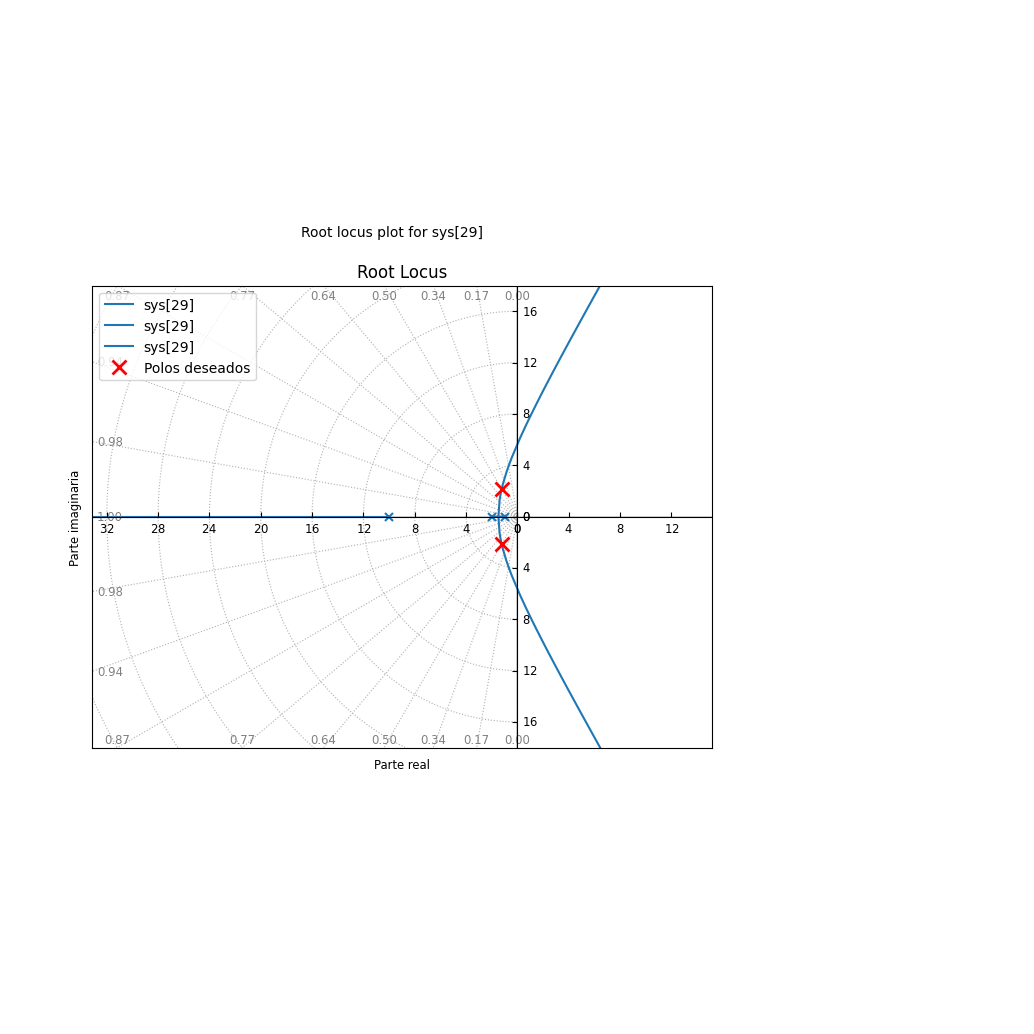

In [9]:
plt.figure(figsize=(8, 6))
ct.root_locus(G, grid=True)

plt.plot(sd.real, sd.imag, 'rx', markersize=10, markeredgewidth=2,
         label='Polos deseados')
plt.plot(sd.real, -sd.imag, 'rx', markersize=10, markeredgewidth=2)

plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.title('Root Locus')
plt.legend()
plt.grid(True)
plt.show()

## Respuesta al escalón

Finalmente, se observa la respuesta al escalón del sistema con la ganancia proporcional calculada.

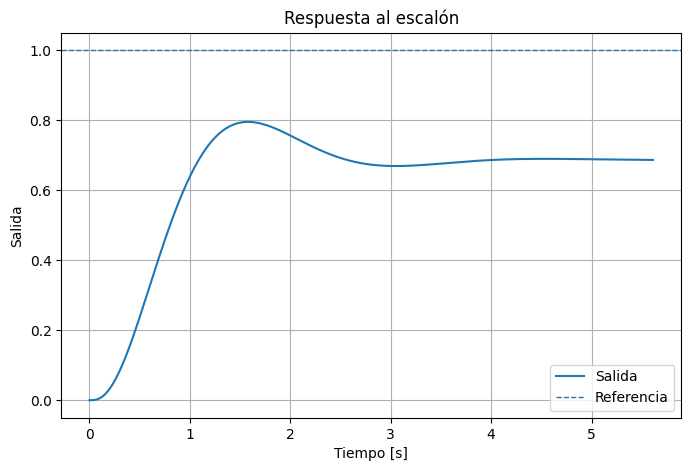

In [10]:
t, y = ct.step_response(T)

plt.figure(figsize=(8, 5))
plt.plot(t, y, label='Salida')
plt.axhline(1, linestyle='--', linewidth=1, label='Referencia')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida')
plt.title('Respuesta al escalón')
plt.grid(True)
plt.legend()
plt.show()